In [3]:
null = None  

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split as tts
from sklearn.preprocessing import StandardScaler as ss  
import seaborn as sns

In [5]:
data = pd.read_csv(r"C:\Users\call2\OneDrive\Dtu\Course\projects\Thermal_Powerline_Dataset.csv")
df=data.copy()
df.head()   



,temp_mean,temp_max,temp_std,delta_to_neighbors,hotspot_fraction,edge_gradient,ambient_temp,load_factor,fault_label
0,15.551703,29.588530,3.119858,-2.633301,0.235083,0.852394,17.289249,0.369457,0
1,40.658826,39.218261,6.388712,4.302309,0.158393,1.321425,38.397564,0.685185,0
2,26.919849,32.873410,3.195176,3.145530,0.242524,1.199511,28.152277,0.357874,0
3,34.785930,42.710556,5.513932,5.858629,0.175205,0.688036,36.703955,0.500022,0
4,62.188449,71.188090,5.550522,5.928670,0.233100,0.596020,44.339685,0.989900,1


In [10]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   temp_mean           6000 non-null   float64
 1   temp_max            6000 non-null   float64
 2   temp_std            6000 non-null   float64
 3   delta_to_neighbors  6000 non-null   float64
 4   hotspot_fraction    6000 non-null   float64
 5   edge_gradient       6000 non-null   float64
 6   ambient_temp        6000 non-null   float64
 7   load_factor         6000 non-null   float64
 8   fault_label         6000 non-null   int64  
dtypes: float64(8), int64(1)
memory usage: 422.0 KB


Index(['temp_mean', 'temp_max', 'temp_std', 'delta_to_neighbors',
       'hotspot_fraction', 'edge_gradient', 'ambient_temp', 'load_factor',
       'fault_label'],
      dtype='object')

In [7]:
df.isnull().sum()

temp_mean             0
temp_max              0
temp_std              0
delta_to_neighbors    0
hotspot_fraction      0
edge_gradient         0
ambient_temp          0
load_factor           0
fault_label           0
dtype: int64

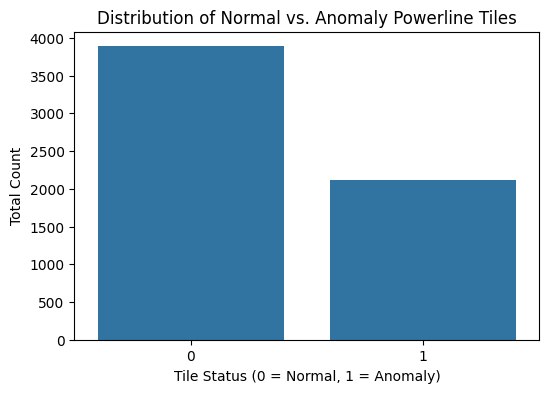

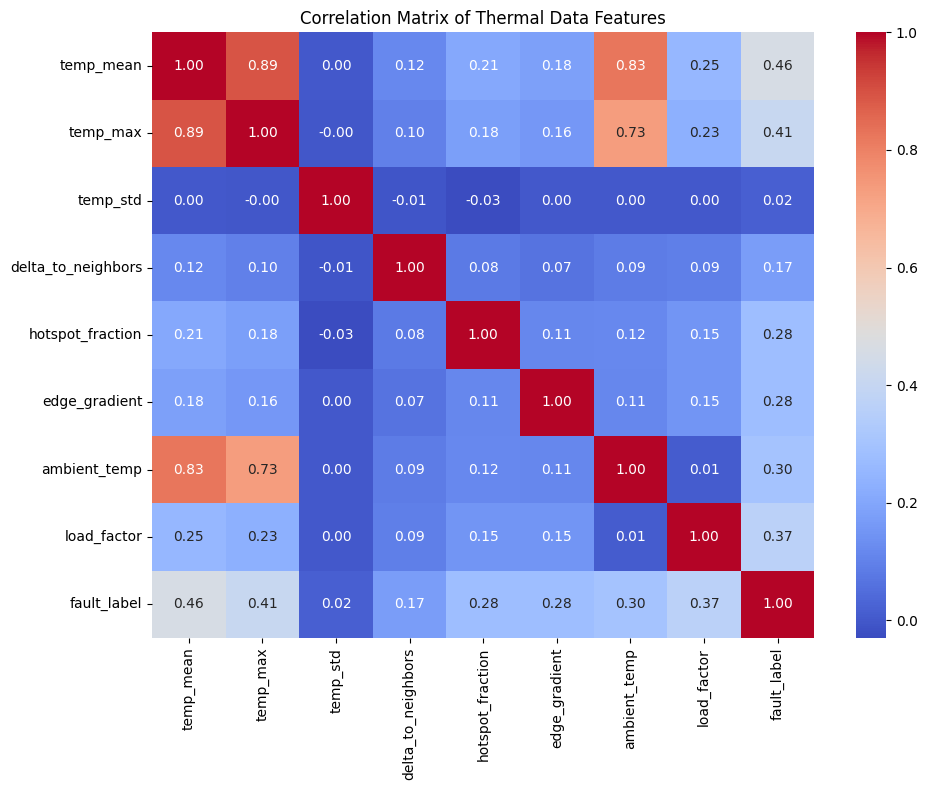

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='fault_label') 
plt.title("Distribution of Normal vs. Anomaly Powerline Tiles")
plt.xlabel("Tile Status (0 = Normal, 1 = Anomaly)")
plt.ylabel("Total Count")
plt.show()


plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Thermal Data Features")
plt.tight_layout()
plt.show()

In [47]:
df['spatial_x']= [i % 100 for i in range(len(df))] 
df['spatial_y']= [i // 100 for i in range(len(df))] 
y=data['fault_label']
x=df.drop(columns=[('fault_label')])
x.info()
y.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   temp_mean           6000 non-null   float64
 1   temp_max            6000 non-null   float64
 2   temp_std            6000 non-null   float64
 3   delta_to_neighbors  6000 non-null   float64
 4   hotspot_fraction    6000 non-null   float64
 5   edge_gradient       6000 non-null   float64
 6   ambient_temp        6000 non-null   float64
 7   load_factor         6000 non-null   float64
 8   spatial_x           6000 non-null   int64  
 9   spatial_y           6000 non-null   int64  
dtypes: float64(8), int64(2)
memory usage: 468.9 KB


0    0
1    0
2    0
3    0
4    1
Name: fault_label, dtype: int64

In [50]:
x_train,x_test,y_train,y_test= tts(x,y, test_size=0.2,stratify=y,random_state=60)
s=ss()
x_train_s=s.fit_transform(x_train)
x_test_s=s.transform(x_test)

In [52]:
from sklearn.ensemble import RandomForestClassifier as rfc
from sklearn.neural_network import MLPClassifier as mlp
from sklearn.metrics import classification_report , confusion_matrix , roc_auc_score 
